In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from search.parallel_gradient import ParallelGradientDescent
from search.tree import WeightedCoordinateDescent
from utils.eval.vis import plt_setup_latex
from utils.sampling import BatchNegativeSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [3]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [4]:
dataset ="si_score_vit_no_crop"
architecture = "vit_b_16_pretrained"

In [5]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)
dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data)


In [6]:
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']



In [7]:
print(len(dataset_train))

85928


In [8]:
print(len(train_loader))


672


In [9]:
dataset_train[2][0].shape

torch.Size([3, 224, 224])

In [10]:
batch_size = next(iter(train_loader))[0].shape[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Text(0.5, 1.0, 'Test')

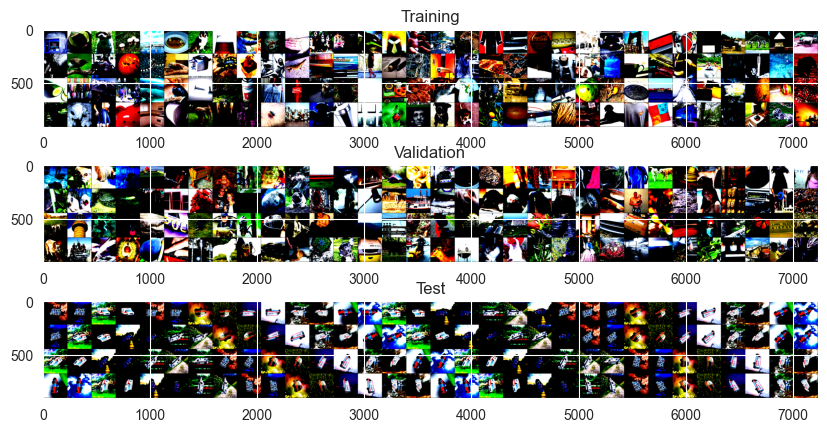

In [11]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader_transformed))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')



In [12]:
from experiment_thesis.main import train_and_get_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")

model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

#if si score then no train
if not "si_score" in dataset:
    train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
            "accelerator": "auto",
            "max_epochs": 100,
            "precision": "16-mixed",
    },load_if_exists=True)


#res = evaluate_base_model(model, test_loader_transformed, device)
#print(res)

In [13]:
#check main model
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.36075320839881897, 'f2_macro': 0.025675050914287567, 'f2_micro': 0.36075320839881897, 'f2_weighted': 0.396980881690979}


{'accuracy': 0.941989541053772, 'f2_macro': 0.9355600476264954, 'f2_micro': 0.941989541053772, 'f2_weighted': 0.9405051469802856}


In [14]:
model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_siscore_vit")
os.makedirs(results_dir_path, exist_ok=True)

transform_name = "rotation"


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

In [15]:
import confidence.direct.logit_based
import utils.affine_transforms

energy = confidence.direct.logit_based.EnergyConfidence()
from utils.transform_sequence import TransformSequence

transformation_sequence = TransformSequence(
    transformations=[
        utils.affine_transforms.AffineTransformation2D.ROTATION.value,
    ],
    domains=[(-torch.pi, torch.pi)],
    device=device,init_method="sobol"
)


In [16]:
test_loader_transformed = torch.utils.data.DataLoader(test_loader_transformed.dataset, batch_size=8, shuffle=False, num_workers=4,pin_memory=True,persistent_workers=True)

In [17]:
transform_seq = transformation_sequence.cuda()

In [18]:
from experiment_thesis.dataset_preperation.get_dataset import get_layer_embedding_cache_config,create_layer_embedding_cache
cache_config = get_layer_embedding_cache_config(dataset, architecture,transform_name=None,dataset_info=dataset_info)
train_cache =create_layer_embedding_cache(model, train_loader_no_shuffle,cache_config, embedding_cache_path, device=device)

In [19]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [20]:
print(list(model.named_modules()))

[('', VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (

In [21]:
model(next(iter(train_loader_no_shuffle))[0].to(device)).max().cpu().detach().numpy()

array(11.487793, dtype=float32)

In [22]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 0)

embeddings_t, final_t, classes_t = train_cache.get_correct_embeddings(layer, capture_modes=layer_io, flatten=True)
dual_output_model = train_cache.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True)


ValueError: get_network_layer not implemented for dataset: si_score_vit_no_crop

In [22]:
cache_train = train_cache

In [23]:
from search.objective_generators import WCD_LATTICE_WRAPPER

wcd = WeightedCoordinateDescent(
    rounds=1,samples_per_dim=[17,])

di = WCD_LATTICE_WRAPPER(wcd)
wcd = None

In [24]:

embeddings_t, final_t, classes_t = cache_train.get_correct_embeddings(layer, capture_modes=layer_io, flatten=True, concat=True)
dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=True, flatten=True)

from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo

from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

input_transform_image = InputTransformImage((3, 3), (128, 7, 7))
input_transform_pca = PCAInputModule(768)
input_transform_random = RandomProjectionModule(1, method="gaussian")

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.000)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple",max_batch_size=1)
model.cuda().eval()
from search.shgo import SHGO

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search

load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_nn_pytorch_pretrained,
    test_loader=val_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("pcknn_layer_0"),show_progress=True,
    repeats=1)




{'repeats': 1,
 'accuracy_mean': 0.8677980303764343,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.854335606098175,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.8677980303764343,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.8648139834403992,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.8677980303764343,
   'f2_macro': 0.854335606098175,
   'f2_micro': 0.8677980303764343,
   'f2_weighted': 0.8648139834403992,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [25]:
energy_confidence = SinglePassConfidence(model, EnergyConfidence())
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search

load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=TransformationProblem(energy_confidence, transform_seq,
                                                                  consolidate_method="consolidate_simple"),
    test_loader=val_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("normal_energy_val"),show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.7699559926986694,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.7533903121948242,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.7699559926986694,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.7646777629852295,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.7699559926986694,
   'f2_macro': 0.7533903121948242,
   'f2_micro': 0.7699559926986694,
   'f2_weighted': 0.7646777629852295,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [26]:
for name, _ in model.named_modules():
    print(name)



conv_proj
encoder
encoder.dropout
encoder.layers
encoder.layers.encoder_layer_0
encoder.layers.encoder_layer_0.ln_1
encoder.layers.encoder_layer_0.self_attention
encoder.layers.encoder_layer_0.self_attention.out_proj
encoder.layers.encoder_layer_0.dropout
encoder.layers.encoder_layer_0.ln_2
encoder.layers.encoder_layer_0.mlp
encoder.layers.encoder_layer_0.mlp.0
encoder.layers.encoder_layer_0.mlp.1
encoder.layers.encoder_layer_0.mlp.2
encoder.layers.encoder_layer_0.mlp.3
encoder.layers.encoder_layer_0.mlp.4
encoder.layers.encoder_layer_1
encoder.layers.encoder_layer_1.ln_1
encoder.layers.encoder_layer_1.self_attention
encoder.layers.encoder_layer_1.self_attention.out_proj
encoder.layers.encoder_layer_1.dropout
encoder.layers.encoder_layer_1.ln_2
encoder.layers.encoder_layer_1.mlp
encoder.layers.encoder_layer_1.mlp.0
encoder.layers.encoder_layer_1.mlp.1
encoder.layers.encoder_layer_1.mlp.2
encoder.layers.encoder_layer_1.mlp.3
encoder.layers.encoder_layer_1.mlp.4
encoder.layers.encoder_l

In [27]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 1)

embeddings_t, final_t, classes_t = train_cache.get_correct_embeddings(layer, capture_modes=layer_io, flatten=True)
dual_output_model = train_cache.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True)


In [28]:
print()
embeddings_t, final_t, classes_t = cache_train.get_correct_embeddings(layer, capture_modes=layer_io, flatten=True, concat=True)
dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=True, flatten=True)

from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo

from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

input_transform_image = InputTransformImage((3, 3), (128, 7, 7))
input_transform_pca = PCAInputModule(768)
input_transform_random = RandomProjectionModule(1, method="gaussian")

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.000)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple",max_batch_size=1)
model.cuda().eval()
from search.shgo import SHGO

print()
load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_nn_pytorch_pretrained,
    test_loader=val_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("pcknn_layer_1"),show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.8642363548278809,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.851415753364563,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.8642363548278809,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.8611710667610168,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.8642363548278809,
   'f2_macro': 0.851415753364563,
   'f2_micro': 0.8642363548278809,
   'f2_weighted': 0.8611710667610168,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [29]:

embeddings_t, final_t, classes_t = cache_train.get_correct_embeddings(layer, capture_modes=layer_io, flatten=True, concat=True)
dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=True, flatten=True)

from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo

from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

input_transform_image = InputTransformImage((3, 3), (128, 7, 7))
input_transform_pca = PCAInputModule(768)
input_transform_random = RandomProjectionModule(1, method="gaussian")

nn_pytorch_pretrained = PerClassKNNConfidence(metric="mixed", input_transform=None,mixed_alpha=0.5)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.000)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple",max_batch_size=1)
model.cuda().eval()
from search.shgo import SHGO

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search

load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_nn_pytorch_pretrained,
    test_loader=val_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("pcknn_layer_0_mixed"),show_progress=True,
    repeats=1)




{'repeats': 1,
 'accuracy_mean': 0.8684265613555908,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.8558013439178467,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.8684265613555908,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.8655987977981567,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.8684265613555908,
   'f2_macro': 0.8558013439178467,
   'f2_micro': 0.8684265613555908,
   'f2_weighted': 0.8655987977981567,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

Computing embeddings:   0%|          | 0/672 [00:00<?, ?batch/s]


RuntimeError: Selected reducer 'collapse_image' is not applicable for sample_dim=151296.

In [30]:

embeddings_t, final_t, classes_t = cache_train.get_correct_embeddings(layer, capture_modes=layer_io, flatten=True, concat=True)
dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=True, flatten=True)

from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo

from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

input_transform_image = InputTransformImage((3, 3), (128, 7, 7))
input_transform_pca = PCAInputModule(768)
input_transform_random = RandomProjectionModule(1, method="gaussian")

nn_pytorch_pretrained = PerClassKNNConfidence(metric="mixed", input_transform=None,mixed_alpha=0.5)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.000)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple",max_batch_size=1)
model.cuda().eval()
from search.shgo import SHGO

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search

load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("final_results_mixed"),show_progress=True,
    repeats=1)




{'repeats': 4,
 'accuracy_mean': 0.5792399644851685,
 'accuracy_std': 0.0002682130434550345,
 'accuracy_se': 0.00013410652172751725,
 'f2_macro_mean': 0.05054124817252159,
 'f2_macro_std': 0.0007255800883285701,
 'f2_macro_se': 0.00036279004416428506,
 'f2_micro_mean': 0.5792399644851685,
 'f2_micro_std': 0.0002682130434550345,
 'f2_micro_se': 0.00013410652172751725,
 'f2_weighted_mean': 0.613955020904541,
 'f2_weighted_std': 0.00012646688264794648,
 'f2_weighted_se': 6.323344132397324e-05,
 'per_run': [{'accuracy': 0.5790076851844788,
   'f2_macro': 0.04991287738084793,
   'f2_micro': 0.5790076851844788,
   'f2_weighted': 0.6138455271720886,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.5794722437858582,
   'f2_macro': 0.05116961896419525,
   'f2_micro': 0.5794722437858582,
   'f2_weighted': 0.6140645742416382,
   'per_sample_errors': None,
   'per_sam

In [31]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("final_results_mixed"),show_progress=True,
    repeats=2)

{'repeats': 4,
 'accuracy_mean': 0.5792399644851685,
 'accuracy_std': 0.0002682130434550345,
 'accuracy_se': 0.00013410652172751725,
 'f2_macro_mean': 0.05054124817252159,
 'f2_macro_std': 0.0007255800883285701,
 'f2_macro_se': 0.00036279004416428506,
 'f2_micro_mean': 0.5792399644851685,
 'f2_micro_std': 0.0002682130434550345,
 'f2_micro_se': 0.00013410652172751725,
 'f2_weighted_mean': 0.613955020904541,
 'f2_weighted_std': 0.00012646688264794648,
 'f2_weighted_se': 6.323344132397324e-05,
 'per_run': [{'accuracy': 0.5790076851844788,
   'f2_macro': 0.04991287738084793,
   'f2_micro': 0.5790076851844788,
   'f2_weighted': 0.6138455271720886,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.5794722437858582,
   'f2_macro': 0.05116961896419525,
   'f2_micro': 0.5794722437858582,
   'f2_weighted': 0.6140645742416382,
   'per_sample_errors': None,
   'per_sam

In [32]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("final_results_mixed"),show_progress=True,
    repeats=3)

{'repeats': 4,
 'accuracy_mean': 0.5792399644851685,
 'accuracy_std': 0.0002682130434550345,
 'accuracy_se': 0.00013410652172751725,
 'f2_macro_mean': 0.05054124817252159,
 'f2_macro_std': 0.0007255800883285701,
 'f2_macro_se': 0.00036279004416428506,
 'f2_micro_mean': 0.5792399644851685,
 'f2_micro_std': 0.0002682130434550345,
 'f2_micro_se': 0.00013410652172751725,
 'f2_weighted_mean': 0.613955020904541,
 'f2_weighted_std': 0.00012646688264794648,
 'f2_weighted_se': 6.323344132397324e-05,
 'per_run': [{'accuracy': 0.5790076851844788,
   'f2_macro': 0.04991287738084793,
   'f2_micro': 0.5790076851844788,
   'f2_weighted': 0.6138455271720886,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.5794722437858582,
   'f2_macro': 0.05116961896419525,
   'f2_micro': 0.5794722437858582,
   'f2_weighted': 0.6140645742416382,
   'per_sample_errors': None,
   'per_sam

In [33]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("final_results_mixed"),show_progress=True,
    repeats=4)

{'repeats': 4,
 'accuracy_mean': 0.5792399644851685,
 'accuracy_std': 0.0002682130434550345,
 'accuracy_se': 0.00013410652172751725,
 'f2_macro_mean': 0.05054124817252159,
 'f2_macro_std': 0.0007255800883285701,
 'f2_macro_se': 0.00036279004416428506,
 'f2_micro_mean': 0.5792399644851685,
 'f2_micro_std': 0.0002682130434550345,
 'f2_micro_se': 0.00013410652172751725,
 'f2_weighted_mean': 0.613955020904541,
 'f2_weighted_std': 0.00012646688264794648,
 'f2_weighted_se': 6.323344132397324e-05,
 'per_run': [{'accuracy': 0.5790076851844788,
   'f2_macro': 0.04991287738084793,
   'f2_micro': 0.5790076851844788,
   'f2_weighted': 0.6138455271720886,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.5794722437858582,
   'f2_macro': 0.05116961896419525,
   'f2_micro': 0.5794722437858582,
   'f2_weighted': 0.6140645742416382,
   'per_sample_errors': None,
   'per_sam

In [34]:
problem_energy_logits = TransformationProblem(energy_confidence, transform_seq,
                                                      consolidate_method="consolidate_simple",max_batch_size=1)

load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("final_results_energy"),show_progress=True,
    repeats=1)

{'repeats': 4,
 'accuracy_mean': 0.514572024345398,
 'accuracy_std': 0.0016467387322336435,
 'accuracy_se': 0.0008233693661168218,
 'f2_macro_mean': 0.04432132840156555,
 'f2_macro_std': 7.319297583308071e-05,
 'f2_macro_se': 3.6596487916540354e-05,
 'f2_micro_mean': 0.514572024345398,
 'f2_micro_std': 0.0016467387322336435,
 'f2_micro_se': 0.0008233693661168218,
 'f2_weighted_mean': 0.5510760545730591,
 'f2_weighted_std': 0.001741551561281085,
 'f2_weighted_se': 0.0008707757806405425,
 'per_run': [{'accuracy': 0.5159811973571777,
   'f2_macro': 0.04435952007770538,
   'f2_micro': 0.5159811973571777,
   'f2_weighted': 0.5525782108306885,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.5159811973571777,
   'f2_macro': 0.04435952007770538,
   'f2_micro': 0.5159811973571777,
   'f2_weighted': 0.5525782108306885,
   'per_sample_errors': None,
   'per_sample_m

In [35]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("final_results_energy"),show_progress=True,
    repeats=2)

{'repeats': 4,
 'accuracy_mean': 0.514572024345398,
 'accuracy_std': 0.0016467387322336435,
 'accuracy_se': 0.0008233693661168218,
 'f2_macro_mean': 0.04432132840156555,
 'f2_macro_std': 7.319297583308071e-05,
 'f2_macro_se': 3.6596487916540354e-05,
 'f2_micro_mean': 0.514572024345398,
 'f2_micro_std': 0.0016467387322336435,
 'f2_micro_se': 0.0008233693661168218,
 'f2_weighted_mean': 0.5510760545730591,
 'f2_weighted_std': 0.001741551561281085,
 'f2_weighted_se': 0.0008707757806405425,
 'per_run': [{'accuracy': 0.5159811973571777,
   'f2_macro': 0.04435952007770538,
   'f2_micro': 0.5159811973571777,
   'f2_weighted': 0.5525782108306885,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.5159811973571777,
   'f2_macro': 0.04435952007770538,
   'f2_micro': 0.5159811973571777,
   'f2_weighted': 0.5525782108306885,
   'per_sample_errors': None,
   'per_sample_m

In [36]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("final_results_energy"),show_progress=True,
    repeats=3)

{'repeats': 4,
 'accuracy_mean': 0.514572024345398,
 'accuracy_std': 0.0016467387322336435,
 'accuracy_se': 0.0008233693661168218,
 'f2_macro_mean': 0.04432132840156555,
 'f2_macro_std': 7.319297583308071e-05,
 'f2_macro_se': 3.6596487916540354e-05,
 'f2_micro_mean': 0.514572024345398,
 'f2_micro_std': 0.0016467387322336435,
 'f2_micro_se': 0.0008233693661168218,
 'f2_weighted_mean': 0.5510760545730591,
 'f2_weighted_std': 0.001741551561281085,
 'f2_weighted_se': 0.0008707757806405425,
 'per_run': [{'accuracy': 0.5159811973571777,
   'f2_macro': 0.04435952007770538,
   'f2_micro': 0.5159811973571777,
   'f2_weighted': 0.5525782108306885,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.5159811973571777,
   'f2_macro': 0.04435952007770538,
   'f2_micro': 0.5159811973571777,
   'f2_weighted': 0.5525782108306885,
   'per_sample_errors': None,
   'per_sample_m

In [37]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=di, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("final_results_energy"),show_progress=True,
    repeats=4)

{'repeats': 4,
 'accuracy_mean': 0.514572024345398,
 'accuracy_std': 0.0016467387322336435,
 'accuracy_se': 0.0008233693661168218,
 'f2_macro_mean': 0.04432132840156555,
 'f2_macro_std': 7.319297583308071e-05,
 'f2_macro_se': 3.6596487916540354e-05,
 'f2_micro_mean': 0.514572024345398,
 'f2_micro_std': 0.0016467387322336435,
 'f2_micro_se': 0.0008233693661168218,
 'f2_weighted_mean': 0.5510760545730591,
 'f2_weighted_std': 0.001741551561281085,
 'f2_weighted_se': 0.0008707757806405425,
 'per_run': [{'accuracy': 0.5159811973571777,
   'f2_macro': 0.04435952007770538,
   'f2_micro': 0.5159811973571777,
   'f2_weighted': 0.5525782108306885,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.5159811973571777,
   'f2_macro': 0.04435952007770538,
   'f2_micro': 0.5159811973571777,
   'f2_weighted': 0.5525782108306885,
   'per_sample_errors': None,
   'per_sample_m

In [38]:
import torch
import matplotlib.pyplot as plt
import torchvision
from matplotlib.backends.backend_pdf import PdfPages

# --- Unnormalize helper ---
def unnormalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    mean = torch.tensor(mean,device=img.device).view(3, 1, 1)
    std = torch.tensor(std,device=img.device).view(3, 1, 1)
    return img * std + mean


def show_and_save_batch(loader, title, nrow=4, pdf_prefix="output"):
    imgs, _ = next(iter(loader))

    # Unnormalize
    imgs_unnorm = unnormalize(imgs)

    # Ensure enough images for a good grid
    if len(imgs_unnorm) < nrow * nrow:
        imgs2, _ = next(iter(loader))
        imgs_unnorm = torch.cat([imgs_unnorm, unnormalize(imgs2)], dim=0)

    # Build image grid
    grid = torchvision.utils.make_grid(
        imgs_unnorm[:nrow * nrow], nrow=nrow
    ).permute(1, 2, 0).cpu().clip(0, 1)

    # Show
    plt.figure(figsize=(10, 10))
    plt.imshow(grid)
    plt.axis("off")
    plt.show()

    # Save grid as ONE PDF, using your savepath()
    pdf_file = savepath(f"{pdf_prefix}_{title}.pdf")
    #remove json ending
    pdf_file = pdf_file.replace(".json", "")
    with PdfPages(pdf_file) as pdf:
        fig = plt.figure(figsize=(10, 10))
        plt.imshow(grid)
        plt.axis("off")
        pdf.savefig(fig)
        plt.close(fig)

    print(f"Saved PDF grid → {pdf_file}")





In [39]:
W = plt_setup_latex()

In [40]:
import torch
import numpy as np
import tqdm
from numpy.testing import assert_array_equal, assert_allclose

def test_loader_determinism(loader, num_batches_to_test: int = 5):
    """Tests if iterating a PyTorch DataLoader twice yields identical results."""

    print(f"Testing loader determinism over the first {num_batches_to_test} batches...")

    # --- Run 1: Collect first N batches ---
    run1_data, run1_labels = [], []
    loader_iter1 = iter(loader)
    for _ in tqdm.tqdm(range(num_batches_to_test), desc="Run 1"):
        try:
            x, y = next(loader_iter1)
            run1_data.append(x)
            run1_labels.append(y)
        except StopIteration:
            break

    # --- Run 2: Collect first N batches ---
    run2_data, run2_labels = [], []
    loader_iter2 = iter(loader)
    for _ in tqdm.tqdm(range(num_batches_to_test), desc="Run 2"):
        try:
            x, y = next(loader_iter2)
            run2_data.append(x)
            run2_labels.append(y)
        except StopIteration:
            break

    # --- Comparison ---
    if len(run1_data) != len(run2_data):
        print(f"❌ ERROR: Run 1 yielded {len(run1_data)} batches, Run 2 yielded {len(run2_data)} batches.")
        return False

    for i in range(len(run1_data)):
        # 1. Check Labels (must be exact)
        try:
            assert_array_equal(run1_labels[i].numpy(), run2_labels[i].numpy())
        except AssertionError as e:
            print(f"❌ FAILED on Batch {i}: Labels are not identical.")
            print(e)
            return False

        # 2. Check Data (allowing for float precision, though it should be exact)
        try:
            # Use allclose with a small tolerance for floating point numbers
            # If the data includes non-deterministic noise/augmentations, this will fail.
            assert torch.allclose(run1_data[i], run2_data[i], atol=1e-6)
        except AssertionError as e:
            print(f"❌ FAILED on Batch {i}: Data tensors are not identical (max diff: {(run1_data[i] - run2_data[i]).abs().max()}).")
            print("This indicates randomness in the data loading or augmentation pipeline.")
            return False

    print("✅ SUCCESS: Data loader is deterministic for the tested batches.")
    return True

# --- USAGE ---
# test_loader_determinism(test_loader_transformed)

In [41]:
# python
# --- Tradeoff utilities (copy into `experiment_thesis/imagenet_resnet.ipynb`) ---
import os
import numpy as np
import torch
import tqdm
import matplotlib.pyplot as plt

# Ensure result dirs
results_dir_trade = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_tradeoff")
os.makedirs(results_dir_trade, exist_ok=True)
os.makedirs(os.path.dirname(os.path.join(embedding_cache_path, dataset, architecture, transform_name, "dummy")), exist_ok=True)

def default_cache_path(label: str):
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(embedding_cache_path, dataset, architecture, transform_name, f"{safe}_cached_confidences.npz")

@torch.no_grad()
def calculate_confidences_and_cache(
    optimizer,
    best_problem,
    conf_fn,
    test_loader,
    test_loader_transformed,
    device,
    n_runs: int = 5,
    cache_path: str = "cached_confidences.npz",
    force_recompute: bool = False,
    augment_true_func=None,
):
    if os.path.exists(cache_path) and not force_recompute:
        print(f"✅ Loading cached results from {cache_path}")
        return dict(np.load(cache_path, allow_pickle=True))

    print("=== Calculating base confidences (no optimization) ===")
    assert test_loader_determinism(test_loader, num_batches_to_test=3), "Test loader is not deterministic!"
    assert test_loader_determinism(test_loader_transformed, num_batches_to_test=3), "Transformed test loader is not deterministic!"

    def eval_conf(loader, augment_func=None):
        all_conf, correct = [], []
        for x_test, y_test in tqdm.tqdm(loader):
            x_test = x_test.to(device)
            if augment_func is not None:
                x_test = augment_func(x_test)
            conf_values, logits = conf_fn(x_test)
            if logits is None:
                logits = model(x_test)
            pred_y = torch.argmax(logits, dim=1).cpu()
            correct.append((pred_y == y_test).numpy())
            all_conf.append(conf_values.cpu().numpy())
        return np.concatenate(correct), np.concatenate(all_conf)

    correct_predicted, all_conf = eval_conf(test_loader, augment_true_func)
    correct_predicted_transformed, all_conf_transformed = eval_conf(test_loader_transformed)

    results = {
        "correct_predicted": correct_predicted,
        "all_conf": all_conf,
        "correct_predicted_transformed": correct_predicted_transformed,
        "all_conf_transformed": all_conf_transformed,
    }

    print("\n=== Running probabilistic optimizer ===")

    optimized_correct_runs, optimized_conf_runs = [], []
    optimized_correct_runs_t, optimized_conf_runs_t = [], []

    for run_idx in range(n_runs):
        print(f"\n--- Optimization run {run_idx + 1}/{n_runs} ---")

        correct_run, conf_run = [], []
        for x_test, y_test in tqdm.tqdm(test_loader, desc=f"Test run {run_idx+1}"):
            x_test = x_test.to(device)
            p, error, _ = optimizer.optimize(best_problem, x_test)
            x_optimized = best_problem.transform_sequence.transform(x_test, p)
            conf_values, logits = conf_fn(x_optimized)
            if logits is None:
                logits = model(x_optimized)
            pred_y = torch.argmax(logits, dim=1).cpu()
            correct_run.append((pred_y == y_test).numpy())
            conf_run.append(conf_values.cpu().numpy())
        optimized_correct_runs.append(np.concatenate(correct_run))
        optimized_conf_runs.append(np.concatenate(conf_run))

        correct_run_t, conf_run_t = [], []
        for x_test, y_test in tqdm.tqdm(test_loader_transformed, desc=f"Transformed run {run_idx+1}"):
            x_test = x_test.to(device)
            p, error, _ = optimizer.optimize(best_problem, x_test)
            x_optimized = best_problem.transform_sequence.transform(x_test, p)
            conf_values, logits = conf_fn(x_optimized)
            if logits is None:
                logits = model(x_optimized)
            pred_y = torch.argmax(logits, dim=1).cpu()
            correct_run_t.append((pred_y == y_test).numpy())
            conf_run_t.append(conf_values.cpu().numpy())
        optimized_correct_runs_t.append(np.concatenate(correct_run_t))
        optimized_conf_runs_t.append(np.concatenate(conf_run_t))

    results["optimized_correct_predicted"] = np.stack(optimized_correct_runs, axis=1)
    results["optimized_all_conf"] = np.stack(optimized_conf_runs, axis=1)
    results["optimized_correct_predicted_transformed"] = np.stack(optimized_correct_runs_t, axis=1)
    results["optimized_all_conf_transformed"] = np.stack(optimized_conf_runs_t, axis=1)

    np.savez_compressed(cache_path, **results)
    print(f"\n💾 Cached results saved to: {cache_path}")
    return results

def plot_confidence_threshold_results(
    results: dict,
    dataset_name: str = "Dataset",
    use_only_improved: bool = True,
    improvement_metric: str = "confidence",
    relative_improvement: float = 0.0,
    ci_multiplier: float = 1.96,
    lower_quantile: float = 0.001,
    upper_quantile: float = 1.0,
    plot_ratio=True,
    save_path =None,
):
    if improvement_metric != "confidence":
        raise ValueError("Only improvement_metric='confidence' is supported.")

    all_conf = results["all_conf"]
    all_conf_t = results["all_conf_transformed"]
    corr = results["correct_predicted"]
    corr_t = results["correct_predicted_transformed"]
    opt_corr = results["optimized_correct_predicted"]
    opt_corr_t = results["optimized_correct_predicted_transformed"]
    opt_conf = results["optimized_all_conf"]
    opt_conf_t = results["optimized_all_conf_transformed"]

    min_conf = float(min(all_conf.min(), all_conf_t.min()))
    max_conf = float(max(all_conf.max(), all_conf_t.max()))
    conf_range = max_conf - min_conf
    if conf_range <= 0 and relative_improvement > 0:
        raise ValueError("confidence range is zero, cannot apply relative_improvement")

    ql = np.quantile(all_conf_t, lower_quantile)
    qh = np.quantile(all_conf_t, upper_quantile)
    if qh <= ql:
        qh = float(max(all_conf.max(), all_conf_t.max()))

    thresholds = np.linspace(ql, qh, 400)
    n_runs = opt_conf.shape[1]

    acc_orig_runs, acc_trans_runs = [], []
    ratio_orig_runs, ratio_trans_runs = [], []

    for r in range(n_runs):
        acc_o, acc_t = [], []
        ratio_o, ratio_t = [], []
        for thr in thresholds:
            applied_o = all_conf <= thr
            applied_t = all_conf_t <= thr
            improved_o = opt_conf[:, r] >= all_conf
            improved_t = opt_conf_t[:, r] >= all_conf_t

            if relative_improvement > 0.0:
                rel_imp_o = (opt_conf[:, r] - all_conf) / conf_range
                rel_imp_t = (opt_conf_t[:, r] - all_conf_t) / conf_range
                improved_o = np.logical_and(improved_o, rel_imp_o >= relative_improvement)
                improved_t = np.logical_and(improved_t, rel_imp_t >= relative_improvement)

            attempted_o = np.logical_and(applied_o, improved_o)
            attempted_t = np.logical_and(applied_t, improved_t)

            ratio_o.append(applied_o.mean())
            ratio_t.append(applied_t.mean())

            if use_only_improved:
                use_opt_o = attempted_o
                use_opt_t = attempted_t
            else:
                use_opt_o = applied_o
                use_opt_t = applied_t

            final_corr_o = np.where(use_opt_o, opt_corr[:, r], corr)
            final_corr_t = np.where(use_opt_t, opt_corr_t[:, r], corr_t)
            acc_o.append(final_corr_o.mean())
            acc_t.append(final_corr_t.mean())

        acc_orig_runs.append(acc_o)
        acc_trans_runs.append(acc_t)
        ratio_orig_runs.append(ratio_o)
        ratio_trans_runs.append(ratio_t)

    acc_orig_runs = np.array(acc_orig_runs)
    acc_trans_runs = np.array(acc_trans_runs)
    ratio_orig_runs = np.array(ratio_orig_runs)
    ratio_trans_runs = np.array(ratio_trans_runs)

    def compute_ci(y):
        n = y.shape[0]
        mean = y.mean(axis=0)
        if n <= 1:
            se = np.zeros_like(mean)
        else:
            se = y.std(axis=0, ddof=1) / np.sqrt(n)
        return mean, mean - ci_multiplier * se, mean + ci_multiplier * se

    fig, ax1 = plt.subplots(figsize=(W, W/2))
    tab10 = plt.get_cmap("tab10")
    col_o, col_t, col_ro, col_rt, col_hline = tab10(0), tab10(1), tab10(2), tab10(3), tab10(4)

    m_o, lo_o, hi_o = compute_ci(acc_orig_runs)
    m_t, lo_t, hi_t = compute_ci(acc_trans_runs)
    ax1.plot(thresholds, m_o, label="Acc Original", linewidth=2.0, color=col_o)
    ax1.fill_between(thresholds, lo_o, hi_o, alpha=0.15, color=col_o)
    ax1.plot(thresholds, m_t, label="Acc Transformed", linewidth=2.0, color=col_t)
    ax1.fill_between(thresholds, lo_t, hi_t, alpha=0.15, color=col_t)

    ax1.set_xlabel("Confidence Threshold")
    ax1.set_ylabel("Accuracy")
    ax1.grid(True, linestyle=":", alpha=0.7)

    if plot_ratio:
        ax2 = ax1.twinx()
        rm_o, rlo_o, rhi_o = compute_ci(ratio_orig_runs)
        rm_t, rlo_t, rhi_t = compute_ci(ratio_trans_runs)
        ax2.plot(thresholds, rm_o, linestyle="--", linewidth=1.8, color=col_ro, label="Ratio Original")
        ax2.fill_between(thresholds, rlo_o, rhi_o, alpha=0.15, color=col_ro)
        ax2.plot(thresholds, rm_t, linestyle="--", linewidth=1.8, color=col_rt, label="Ratio Transformed")
        ax2.fill_between(thresholds, rlo_t, rhi_t, alpha=0.15, color=col_rt)
        ax2.set_ylabel("Optimization Ratio")

    ax1.set_xlim(ql, qh)

    lines1, labels1 = ax1.get_legend_handles_labels()
    if plot_ratio:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", fontsize=8, framealpha=0.85)
    else:
        ax1.legend(lines1, labels1, loc="center left", fontsize=8, framealpha=0.85)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

    best_idx_o = np.argmax(m_o)
    best_idx_t = np.argmax(m_t)
    print(f"[{dataset_name}]")
    print(f"Max acc (original): {m_o[best_idx_o]:.4f} @ thr={thresholds[best_idx_o]:.4f}")
    print(f"Max acc (transf.): {m_t[best_idx_t]:.4f} @ thr={thresholds[best_idx_t]:.4f}")



In [42]:
# from datasets import load_dataset
# from tqdm import tqdm
# from PIL import Image
# import os
#
# # --------------------------
# # SETTINGS (CHANGE THESE)
# # --------------------------
# SPLIT = "validation"                          # "train" / "validation" / "test"
# SAVE_DIR = "D:/imagenet_full_val"      # where to save images
# # --------------------------
#
# # Load dataset in streaming mode (best for huge datasets)
# ds = load_dataset(
#     "ILSVRC/imagenet-1k",
#     split=SPLIT,
#     streaming=True,
#     trust_remote_code=True
# )
#
# # Create base directory
# os.makedirs(SAVE_DIR, exist_ok=True)
#
# # Count tracker (optional)
# counts = {}
#
# # Progress bar
# pbar = tqdm(ds, desc=f"Saving {SPLIT}", unit="images")
#
# for i, sample in enumerate(pbar):
#     img = sample["image"]
#     label = sample["label"]
#
#     # Track per-class count
#     if label not in counts:
#         counts[label] = 0
#
#     # Create class folder
#     class_dir = os.path.join(SAVE_DIR, str(label))
#     os.makedirs(class_dir, exist_ok=True)
#
#     # File path
#     filename = os.path.join(class_dir, f"{counts[label]:06d}.jpg")
#
#     # Skip existing files → enables RESUMABLE downloads
#     if os.path.exists(filename):
#         counts[label] += 1
#         continue
#
#     # Save image
#     img = img.convert("RGB")
#     img.save(filename, "JPEG")
#
#     counts[label] += 1
#
#     # Update tqdm description
#     pbar.set_description(f"Saving {SPLIT} | Class {label}: {counts[label]} images")
#
# pbar.close()
#
# print("\n✔ Completed download of full split:", SPLIT)
# print("✔ Saved to:", SAVE_DIR)


In [43]:
from torchvision import models
from dataset.si_score import ImageNetSubset

# Use ViT preprocessing for SI-Score dataset
vit_transform = models.ViT_B_16_Weights.IMAGENET1K_V1.transforms()




imagenet_dataset_val = ImageNetSubset(root="D:/imagenet_full_val",
                                  transform=vit_transform)

loader_in = torch.utils.data.DataLoader(imagenet_dataset_val, batch_size=32, shuffle=False, num_workers=4,
                                              pin_memory=True, persistent_workers=True)


✅ Loading cached results from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\embedding_cache\si_score\vit_b_16_pretrained\rotation\imagenet_tradeoff2_cached_confidences.npz


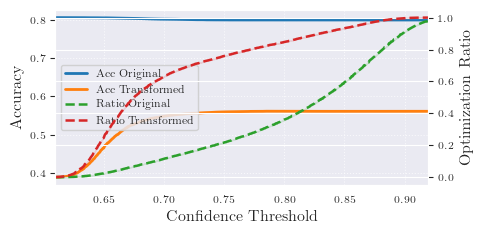

[si_score]
Max acc (original): 0.8055 @ thr=0.6257
Max acc (transf.): 0.5611 @ thr=0.8040
Saved plot to: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\si_score\vit_b_16_pretrained\comparison_tradeoff\confidence_threshold.pdf


In [44]:



problem_to_use = problem_nn_pytorch_pretrained



conf_fn = problem_to_use.confidence_module


optimizer_obj = di


cache_file = default_cache_path("imagenet_tradeoff2")
results = calculate_confidences_and_cache(
    optimizer=optimizer_obj,
    best_problem=problem_to_use,
    conf_fn=conf_fn,
    test_loader=loader_in,
    test_loader_transformed=test_loader_transformed,
    device=device,
    n_runs=1,
    cache_path=cache_file,
)

plot_confidence_threshold_results(results, dataset_name=dataset, save_path=os.path.join(results_dir_trade, "confidence_threshold.pdf"),use_only_improved=True,relative_improvement=0.1)
print("Saved plot to:", os.path.join(results_dir_trade, "confidence_threshold.pdf"))

In [45]:
import torch
import numpy as np
import tqdm

@torch.no_grad()
def evaluate_at_threshold(
    optimizer,
    problem,
    conf_fn,
    test_loader_transformed,
    device,
    threshold: float = 0.8,
):
    all_correct = []
    total_samples = 0
    correct_count = 0
    attempted_opt = 0
    successful_opt = 0

    pbar = tqdm.tqdm(test_loader_transformed, desc=f"Evaluating @ threshold {threshold}")

    for x_test, y_test in pbar:
        x_test = x_test.to(device)
        batch_size = x_test.shape[0]

        # 1. Get baseline confidence
        conf_baseline, logits_baseline = conf_fn(x_test)
        if logits_baseline is None:
            logits_baseline = model(x_test)
        pred_baseline = torch.argmax(logits_baseline, dim=1)

        # 2. Identify samples below threshold
        below_threshold = conf_baseline < threshold

        final_pred = pred_baseline.clone()

        if below_threshold.any():
            attempted_opt += below_threshold.sum().item()

            # --- FIX: OPTIMIZE FULL BATCH TO PRESERVE STATS ---
            # Even though we only care about 'below_threshold',
            # we pass the full x_test to the optimizer so it sees
            # the same statistics as your simulation.
            p, _, _ = optimizer.optimize(problem, x_test)

            # Transform the inputs
            x_optimized_full = problem.transform_sequence.transform(x_test, p)

            # 3. Check Confidence on the optimized images
            # We only calculate confidence for the relevant ones to save compute,
            # or calculate full and mask. Calculating full is safer for indexing.
            conf_opt_full, logits_opt_full = conf_fn(x_optimized_full)
            if logits_opt_full is None:
                logits_opt_full = model(x_optimized_full)
            pred_opt_full = torch.argmax(logits_opt_full, dim=1)

            # 4. Accept optimization ONLY if confidence improved
            # logic: (Below Threshold) AND (New Conf > Old Conf)
            improved_mask = (conf_opt_full > conf_baseline) & below_threshold

            successful_opt += improved_mask.sum().item()

            # Update predictions for the improved samples
            final_pred[improved_mask] = pred_opt_full[improved_mask]

        # Compute correctness
        correct = (final_pred.cpu() == y_test).numpy()
        correct_count += correct.sum()
        total_samples += batch_size

        current_acc = correct_count / total_samples
        pbar.set_postfix({"Acc": f"{current_acc:.4f}"})

    final_acc = correct_count / total_samples
    opt_ratio = attempted_opt / total_samples
    success_ratio = successful_opt / attempted_opt if attempted_opt > 0 else 0

    print(f"\n=== Results at threshold {threshold} ===")
    print(f"Final Accuracy: {final_acc:.4f}")
    return final_acc


test_loader_transformed_shuffle= torch.utils.data.DataLoader(
    test_loader_transformed.dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

#print("")
# Run evaluation
# results_threshold = evaluate_at_threshold(
#     optimizer=di,
#     problem=problem_nn_pytorch_pretrained,
#     conf_fn=problem_nn_pytorch_pretrained.confidence_module,
#     test_loader_transformed=test_loader_transformed_shuffle,
#     device=device,
#     threshold=0.8
# )

In [46]:
stop

NameError: name 'stop' is not defined

In [ ]:
from typing import Optional
def visualize_canonicalization_grid(
    model,
    optimizer,
    problem,
    test_loader,
    n_rows: int = 4,
    n_cols: int = 4,
    device: str = "cuda",
    save_prefix: Optional[str] = None
):
    """
    Visualize images before and after canonicalization in a 4x4 grid.
    Green border = correct classification, Red border = incorrect.

    Args:
        save_prefix: If provided, saves {prefix}_before.pdf and {prefix}_after.pdf
    """
    model.eval()
    n_samples = n_rows * n_cols

    # Get a batch of data
    data, target = next(iter(test_loader))
    data, target = data.to(device), target.to(device)
    if len(data) < n_samples:
        data2, target2 = next(iter(test_loader))
        data = torch.cat([data, data2.to(device)], dim=0)
        target = torch.cat([target, target2.to(device)], dim=0)


    data = data[:n_samples]
    target = target[:n_samples]

    # Optimize transformations (canonicalize)
    res = optimizer.optimize(problem, data, y=target)
    params = res[0]
    x_canonicalized = problem.transform(data, params)

    # Get predictions
    with torch.no_grad():
        pred_before = model(data).argmax(dim=-1)
        pred_after = model(x_canonicalized).argmax(dim=-1)

    # unnormalize for visualization
    data = unnormalize(data)
    x_canonicalized = unnormalize(x_canonicalized)
    def add_border(img_tensor, is_correct):
        """Add colored border to image (C, H, W)"""
        color = torch.tensor([0, 1, 0] if is_correct else [1, 0, 0], device=img_tensor.device)
        bordered = img_tensor.clone()

        # Handle grayscale
        if bordered.shape[0] == 1:
            bordered = bordered.repeat(3, 1, 1)

        # Add border (2 pixel width)
        border_width = 2
        for c in range(3):
            bordered[c, :border_width, :] = color[c]
            bordered[c, -border_width:, :] = color[c]
            bordered[c, :, :border_width] = color[c]
            bordered[c, :, -border_width:] = color[c]

        return bordered

    # Create bordered images
    data_bordered = torch.stack([add_border(data[i], pred_before[i] == target[i]) for i in range(n_samples)])
    canon_bordered = torch.stack([add_border(x_canonicalized[i], pred_after[i] == target[i]) for i in range(n_samples)])

    # Create grids
    grid_before = torchvision.utils.make_grid(data_bordered.cpu(), nrow=n_cols, padding=2)
    grid_after = torchvision.utils.make_grid(canon_bordered.cpu(), nrow=n_cols, padding=2)

    # Display side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(grid_before.permute(1, 2, 0))
    axes[0].set_title('Before Canonicalization', fontsize=14)
    axes[0].axis('off')
    axes[1].imshow(grid_after.permute(1, 2, 0))
    axes[1].set_title('After Canonicalization', fontsize=14)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    # Save separate PDFs if requested
    if save_prefix:
        # Before
        fig_before, ax_before = plt.subplots(1, 1, figsize=(8, 8))
        ax_before.imshow(grid_before.permute(1, 2, 0))
        ax_before.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(f"{save_prefix}_before.pdf", bbox_inches='tight', pad_inches=0)
        plt.close(fig_before)

        # After
        fig_after, ax_after = plt.subplots(1, 1, figsize=(8, 8))
        ax_after.imshow(grid_after.permute(1, 2, 0))
        ax_after.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(f"{save_prefix}_after.pdf", bbox_inches='tight', pad_inches=0)
        plt.close(fig_after)

        print(f"Saved: {save_prefix}_before.pdf and {save_prefix}_after.pdf")

    # Print statistics
    acc_before = (pred_before == target).float().mean().item()
    acc_after = (pred_after == target).float().mean().item()

    print(f"Accuracy - Before: {acc_before:.3f}, After: {acc_after:.3f}")

    return {"accuracy_before": acc_before, "accuracy_after": acc_after}

visualize_canonicalization_grid(
    model=model,
    optimizer=di,
    problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed,
    n_rows=4,
    n_cols=4,
    device=device,
    save_prefix=savepath("canonicalization_grid").replace(".json", "")
)